# 딥러닝-분류 모델링(Multi-Class)

MNIST 손글씨 숫자 데이터를 사용해 PyTorch 기반 다중분류 모델을 만들고 비교합니다.

이 노트북의 목표는 다음과 같습니다.

- 이미지 데이터를 PyTorch `DataLoader`와 텐서로 다룬다.
- 다중분류 모델의 출력 노드 수를 클래스 수에 맞춘다.
- 다중분류 손실 함수인 `CrossEntropyLoss`를 사용한다.
- 예측 결과를 `softmax`와 `argmax`로 클래스로 변환한다.
- confusion matrix와 classification report로 모델을 평가한다.

## 1. 환경 준비

필요한 라이브러리를 불러오고, 반복해서 사용할 함수들을 먼저 정의합니다.

### 1.1 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.set_printoptions(linewidth=np.inf)

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor

torch.set_printoptions(linewidth=1000)

### 1.2 필요 함수 생성

아래 3개 함수가 학습 흐름의 핵심입니다.

- `make_DataSet`: pandas/numpy 데이터를 학습용 `DataLoader`와 검증 텐서로 변환합니다.
- `train`: 한 epoch 동안 미니배치 학습을 수행합니다.
- `evaluate`: 검증 또는 테스트 데이터 전체에 대해 손실과 예측값을 반환합니다.

- `make_DataSet` 함수 : 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

- `train` 함수 : 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

- `evaluate` 함수 : 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증/테스트 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

- 학습 곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### 1.4 데이터 셋

MNIST는 0부터 9까지의 손글씨 숫자 이미지 데이터입니다.

- 입력 데이터: 28 x 28 흑백 이미지
- 정답 데이터: 숫자 클래스 0 ~ 9
- 클래스 개수: 10개

- 데이터 다운로드

In [8]:
# train 데이터 다운로드
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),       # 픽셀값을 [0,1] 사이로 정규화하고 텐서로 변환
)

# test 데이터 다운로드
test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

- 데이터셋 일반 정보

In [9]:
train_dataset, test_dataset

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

- 데이터셋의 x와 y

In [10]:
train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

- y(target)의 클래스

In [11]:
train_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

- 데이터 1건 확인

In [12]:
# 첫 번째 요소 : 이미지 데이터(1 x 28 x 28)
# 두 번째 요소 : 정답(레이블)
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.000

- 데이터 이미지 확인

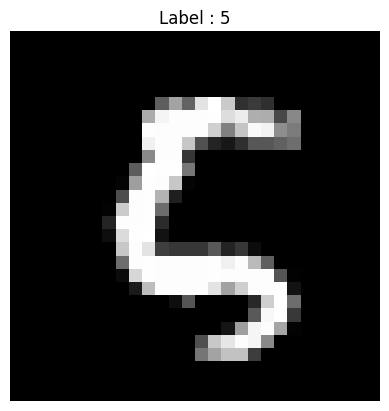

In [13]:
n = 2000
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap='gray')
plt.title(f'Label : {label}')
plt.axis('off')
plt.show()

## 2. 데이터 준비

다운로드한 MNIST 데이터셋은 이미 다음 전처리가 적용되어 있습니다.

- x, y가 분리되어 있음
- train, test가 분리되어 있음
- `ToTensor()`를 통해 학습 데이터의 픽셀값이 [0, 1] 범위로 변환되어 있음

### 2.1 train은 DataLoader로 생성

학습 데이터는 미니배치 단위로 학습할 수 있도록 `DataLoader`로 만듭니다.

In [14]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [15]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_dataloader:
    print(x.shape)
    print(y.shape, y.dtype)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64]) torch.int64


### 2.2 validation, test 준비

`test_dataset`을 validation과 test로 나누어 사용합니다.

- validation : 학습 중 epoch마다 성능 확인
- test : 모델 학습 후 최종 평가

`dataset.data` 속성으로 꺼낸 데이터는 원본 픽셀값이므로 모델링 전에 다음 처리를 수행합니다.

- 스케일링 : 0 ~ 255 값을 0 ~ 1 범위로 변환
- 차원 변환 : `[데이터 수, 28, 28]`에서 `[데이터 수, 1, 28, 28]`로 변환

- 데이터 분할 : test → validation, test

In [16]:
X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

In [17]:
X_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

- 스케일링

In [18]:
test_dataset.data[1]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 116, 125, 171, 255, 255, 150,  93,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0, 169, 253, 253, 253, 253, 253, 253, 218,  30,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0, 169, 253, 253, 253, 213, 142, 176, 253, 253, 122,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,  52, 250, 253, 210,  32,  12,   0,   6, 206, 253, 140,  

In [19]:
# 모든 픽셀값 [0,1] 범위로 변환
X_val = X_val / 255
X_test = X_test / 255

- 3차원 데이터셋 → 4차원 데이터셋

현재 MLP 모델에서는 `Flatten()`으로 펼쳐서 사용하므로 꼭 필요한 작업은 아닙니다. 다만 이후 CNN 모델링에서 이미지 데이터는 `[채널, 세로, 가로]` 구조가 필요하므로 동일한 형태로 준비합니다.

In [20]:
X_val = X_val.view(5000, 1, 28, 28)     # [1 * 28 * 28 이미지 5000장] 구조로 변환
X_test = X_test.view(5000, 1, 28, 28)

print(X_val.shape, X_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## 3. 모델링 1: 은닉층 없는 다중분류 모델 만들기

먼저 이미지를 1차원으로 펼친 뒤, 출력층만 사용해 10개 클래스 중 하나를 예측합니다.

다중분류에서 중요한 점은 다음과 같습니다.

- 출력 노드 수는 클래스 개수와 같아야 합니다.
- `CrossEntropyLoss`는 모델의 출력값(logits)을 내부적으로 softmax 처리하므로 모델 마지막에 `Softmax`를 넣지 않습니다.

### 3.1 모델 선언

In [21]:
n_feature = 28 * 28
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Flatten(),                       # 이미지를 한 줄로 펼치기
    nn.Linear(n_feature, n_class)       # 클래스 수만큼 출력
).to(device)

print(model1)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


- Loss function과 Optimizer

In [22]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.01)

### 3.2 모델 학습

In [23]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.354250, val loss : 0.389721
Epoch 2, train loss : 0.308036, val loss : 0.384157
Epoch 3, train loss : 0.300778, val loss : 0.390701
Epoch 4, train loss : 0.294054, val loss : 0.381325
Epoch 5, train loss : 0.290863, val loss : 0.404655
Epoch 6, train loss : 0.290263, val loss : 0.389431
Epoch 7, train loss : 0.286285, val loss : 0.442785
Epoch 8, train loss : 0.286793, val loss : 0.396520
Epoch 9, train loss : 0.288913, val loss : 0.401592
Epoch 10, train loss : 0.285022, val loss : 0.440978


- 학습 곡선

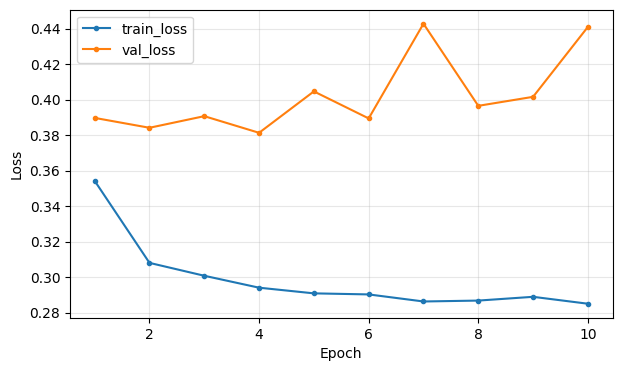

In [24]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 3.3 모델 평가

In [25]:
_, pred = evaluate(X_test, y_test, model1, loss_fn, device)
pred[:5]

tensor([[-6.1500e+00, -1.2219e+01, -4.0375e+00,  3.6982e+00, -4.5552e+00,  5.4759e+00, -1.1461e+01, -1.1096e+01, -4.3105e-01, -2.8924e+00],
        [-1.0733e+01, -2.0043e+01, -3.4440e+00, -5.2892e-03,  3.1291e+00, -2.1265e+00, -5.3669e+00, -2.9363e+00,  1.9488e+00,  5.1034e+00],
        [-1.3964e+01, -2.0628e+01, -1.1491e+01, -6.0922e+00,  5.0250e+00, -8.6604e+00, -1.2504e+01, -5.0646e-01,  2.4491e+00,  1.1055e+01],
        [-1.3427e+01, -1.3910e+01, -7.8782e+00, -2.5596e+00, -1.0077e+01, -5.3060e-01, -1.8590e+01, -1.3263e+01,  9.2448e+00,  2.6865e+00],
        [-6.5689e+00, -2.5929e+01, -6.2979e+00, -9.6967e+00,  1.0375e+01, -3.5288e+00, -9.5792e-01, -6.9091e+00, -2.0395e+00,  2.2219e-02]], device='cuda:0')

- 예측 결과를 각 클래스별 확률값으로 변환 : `nn.functional.softmax()`
- 가장 확률이 높은 클래스 찾기 : `np.argmax()`

In [26]:
pred_prob = nn.functional.softmax(pred, dim=1)      # 클래스별 확률값으로 변환
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1) # 가장 높은 확률의 클래스를 최종 예측값으로 선택
pred_class[:5]


array([5, 9, 9, 8, 4])

- confusion matrix

In [27]:
cm = confusion_matrix(y_test.numpy(), pred_class)
cm

array([[503,   0,   0,   2,   0,   4,   8,   2,   1,   0],
       [  0, 558,   1,   0,   0,   1,   1,   0,   3,   0],
       [  3,   7, 429,  20,   8,   2,   9,   2,  21,   1],
       [  2,   0,   4, 459,   2,  21,   1,   1,  14,   6],
       [  1,   1,   1,   1, 464,   0,   2,   0,   3,   9],
       [  2,   3,   0,   6,   5, 403,   9,   0,   8,   0],
       [  0,   0,   0,   0,   1,   5, 490,   0,   0,   0],
       [  0,   3,   6,   3,   2,   1,   0, 471,   0,  30],
       [  1,  12,   0,   4,   3,   8,  17,   1, 428,  11],
       [  3,   0,   0,   5,   3,   2,   0,   3,   2, 471]])

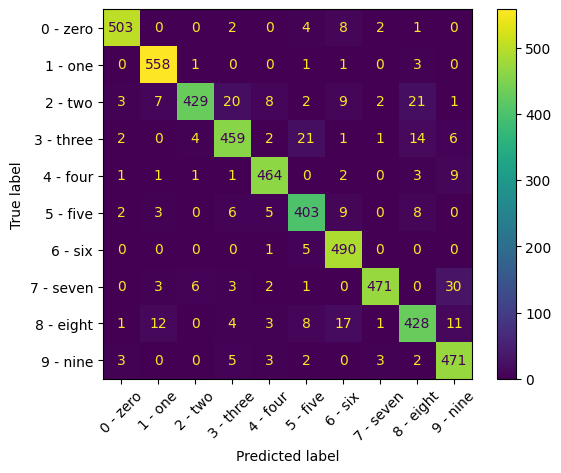

In [28]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
cm_display.plot()
plt.xticks(rotation=45)
plt.show()

- classification_report

In [29]:
print(classification_report(y_test.numpy(), pred_class))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       520
           1       0.96      0.99      0.97       564
           2       0.97      0.85      0.91       502
           3       0.92      0.90      0.91       510
           4       0.95      0.96      0.96       482
           5       0.90      0.92      0.91       436
           6       0.91      0.99      0.95       496
           7       0.98      0.91      0.95       516
           8       0.89      0.88      0.89       485
           9       0.89      0.96      0.93       489

    accuracy                           0.94      5000
   macro avg       0.94      0.93      0.93      5000
weighted avg       0.94      0.94      0.93      5000



---

## 4. 모델링 2: 은닉층 추가

은닉층 수와 노드 수를 조절하며 모델을 설계하고 학습시켜 봅니다.

- 은닉층 활성화 함수는 `ReLU`를 사용합니다.
- 출력층 노드 수는 클래스 수인 10개입니다.
- `CrossEntropyLoss`를 사용하므로 마지막에 `Softmax`는 넣지 않습니다.

### 4.1 모델 선언

In [30]:
model2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 50),
    nn.ReLU(),
    nn.Linear(50,10)        # 총 class 10개
).to(device)

print(model2)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=50, bias=True)
  (4): ReLU()
  (5): Linear(in_features=50, out_features=10, bias=True)
)


- Loss function과 Optimizer

In [31]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.01)

### 4.2 모델 학습

In [32]:
epochs = 20
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.246727, val loss : 0.163714
Epoch 2, train loss : 0.146784, val loss : 0.197661
Epoch 3, train loss : 0.126295, val loss : 0.149627
Epoch 4, train loss : 0.110654, val loss : 0.186334
Epoch 5, train loss : 0.105060, val loss : 0.190223
Epoch 6, train loss : 0.092382, val loss : 0.188714
Epoch 7, train loss : 0.087871, val loss : 0.202241
Epoch 8, train loss : 0.080635, val loss : 0.197884
Epoch 9, train loss : 0.082301, val loss : 0.180854
Epoch 10, train loss : 0.078330, val loss : 0.187396
Epoch 11, train loss : 0.078631, val loss : 0.216909
Epoch 12, train loss : 0.072373, val loss : 0.205221
Epoch 13, train loss : 0.068910, val loss : 0.217526
Epoch 14, train loss : 0.066893, val loss : 0.193221
Epoch 15, train loss : 0.059831, val loss : 0.208636
Epoch 16, train loss : 0.054502, val loss : 0.185501
Epoch 17, train loss : 0.065484, val loss : 0.246875
Epoch 18, train loss : 0.062947, val loss : 0.224509
Epoch 19, train loss : 0.057254, val loss : 0.254161
Ep

- 학습 곡선

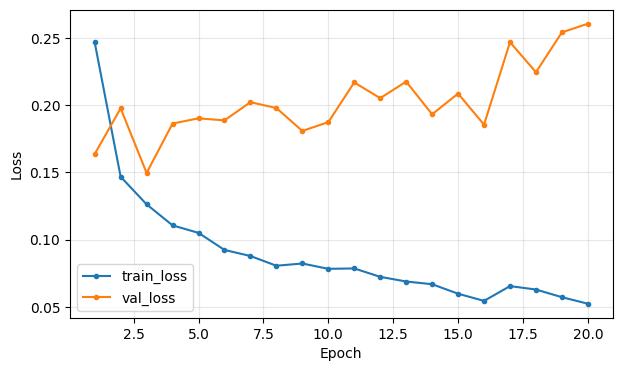

In [33]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 4.3 모델 평가

In [34]:
_, pred = evaluate(X_test, y_test, model2, loss_fn, device)
pred[:5]

tensor([[-10.3320,  -9.3960,   4.6908,  22.9901,  -8.7196,   8.1774, -29.9595, -15.4147,   2.2676,   3.2015],
        [-11.2448,  -9.0387, -33.1738,  -9.7239,   7.7615, -10.5560, -45.7781,  -2.0188, -10.3326,  18.8243],
        [-19.0012, -29.4059, -67.5555, -16.3198,  13.4223, -15.1539, -81.1178,  -1.3938, -29.4054,  41.4153],
        [ -8.5805,   2.2805, -25.8404, -15.6851, -30.1698, -11.4785,   4.3044, -73.3257,  48.4714, -26.0999],
        [-20.0010,  -3.4041, -37.7359, -70.8742,  64.5226, -23.1148, -20.4582, -24.1266, -37.2157,  26.5133]], device='cuda:0')

- 예측 결과를 각 클래스별 확률값으로 변환하고, 가장 확률이 높은 클래스를 최종 예측값으로 선택합니다.

In [35]:
pred_prob = nn.functional.softmax(pred, dim=1)


In [36]:
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)


- confusion matrix

In [37]:
cm = confusion_matrix(y_test.numpy(), pred_class)
cm

array([[515,   0,   0,   0,   0,   2,   1,   1,   1,   0],
       [  0, 559,   0,   0,   0,   1,   1,   0,   3,   0],
       [  1,   1, 489,   0,   2,   0,   1,   2,   6,   0],
       [  0,   0,   3, 499,   0,   1,   0,   2,   3,   2],
       [  0,   2,   0,   0, 472,   0,   0,   1,   5,   2],
       [  2,   0,   0,   5,   0, 425,   2,   0,   2,   0],
       [  1,   0,   0,   0,   1,   2, 491,   0,   1,   0],
       [  1,   1,   3,   0,   0,   0,   0, 509,   0,   2],
       [  5,   1,   0,   1,   1,   4,   1,   0, 470,   2],
       [  1,   0,   0,   1,   2,   0,   0,   2,   2, 481]])

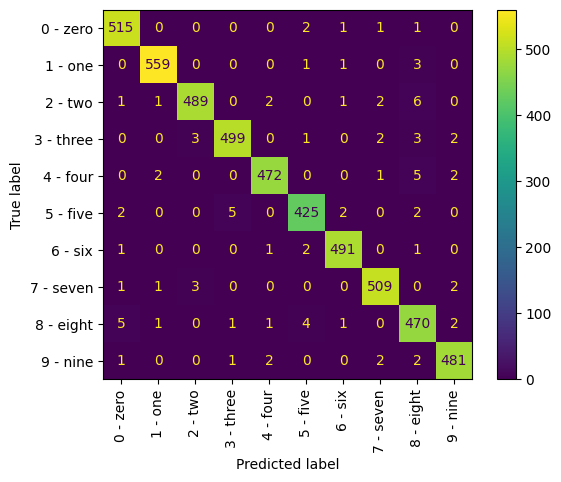

In [38]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

- classification_report

In [39]:
print(classification_report(y_test.numpy(), pred_class))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       520
           1       0.99      0.99      0.99       564
           2       0.99      0.97      0.98       502
           3       0.99      0.98      0.98       510
           4       0.99      0.98      0.98       482
           5       0.98      0.97      0.98       436
           6       0.99      0.99      0.99       496
           7       0.98      0.99      0.99       516
           8       0.95      0.97      0.96       485
           9       0.98      0.98      0.98       489

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



---

## 5. 손글씨 추론

직접 준비한 손글씨 이미지 파일을 MNIST와 같은 형태로 변환한 뒤, 학습된 모델로 숫자를 예측합니다.

- 예시 파일명: `숫자_4.png`
- 이미지가 없는 경우 파일명을 실제 이미지 경로로 변경해야 합니다.

- OpenCV 설치

In [40]:
%pip install opencv-python

- 라이브러리 불러오기

In [41]:
import torchvision.transforms as transforms
from PIL import Image
import cv2

- 이미지 불러오기

In [43]:
model2.eval()

image_path = "숫자_6.png"

# 흰색 배경 → 검은색 배경으로 반전하기 위해 흑백 이미지로 변환
image = Image.open(image_path).convert("L")
image = np.array(image)

- MNIST 스타일로 변환

In [44]:
image = cv2.bitwise_not(image)        # 색 반전
x, y, w, h = cv2.boundingRect(image)  # 숫자 영역 찾기
roi = image[y:y+h, x:x+w]             # 숫자 영역만 자르기
roi = cv2.resize(roi, (28, 28), interpolation=cv2.INTER_AREA)  # MNIST 크기로 변환

- 변환 이미지 저장

In [45]:
Image.fromarray(image).save("processed_image.png")

- PyTorch 텐서 변환

In [46]:
transform = transforms.Compose([
    transforms.ToTensor()  # 학습 데이터와 동일하게 [0, 1] 범위로 변환
])

image_tensor = transform(Image.fromarray(roi)).unsqueeze(0).to(device)

- 예측 수행

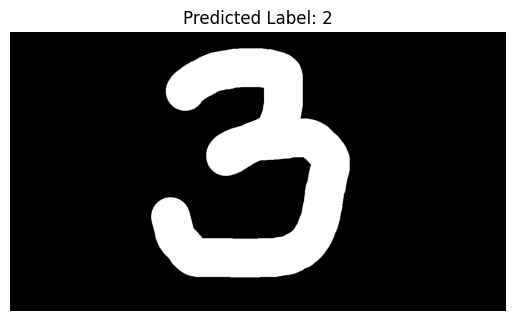

In [47]:
with torch.no_grad():
    output = model2(image_tensor)
    predicted_label = torch.argmax(output, dim=1).item()

plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label}")
plt.axis("off")
plt.show()

In [48]:
print(f"Model device: {next(model2.parameters()).device}")
print(f"Image Tensor device: {image_tensor.device}")

Model device: cuda:0
Image Tensor device: cuda:0
